# Interactive Prototype

Goal: Create a functional MVP for field route planning and management.

Stages:
1. Region Input & Sub-Division
2. Automatic Target Search & Routing
3. Manual Adjustment
4. Select & Execute Plans

Possible Improvements:
- Manually place depots: have it reflect efficiency of placements
- What do we actually deliver to a client/NRCS to prove we did the routes?
    - Maybe ask Cade what he would like to see
- What would we need to change/update before handing this off to Cade?
- Builds into flight-tracking platform?
- How can we package this into something more user friendly?
- TODO: close loop on route waypoint file generation
- Is GPS accurate enough?

## Data Calculation

Here we will load in our "static" data and compute efficient treatment solutions.

This section will cover the raw computation and coding end of things, while the next will allow us to visualize and interact with our solution space.

In [1]:
# General Parameters
# ==================
region_crs = 32613 # Use this everywhere for consistency
visualization_crs = 4326 # Use this when we need leaflet visualizations

# 1a. Work region
region_image_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
region_contour_shapefile = '../input/interactive_proto/region_contour.shp'
region_contour_geojson = '../input/interactive_proto/region_contour.geojson'
region_name = 'Brewster_57' # To associate cells, targets with region
region_version = '2024-12-14'
simplification_tolerance = 5

# 1b. Cell generation parameters
target_area_acres = 0.5
# target_area_acres = 1.5
# target_area_acres = 2.5
target_area_sqm = target_area_acres * 4046.86
max_iterations = 15 # Cycles to find improved partition
voronoi_partition_filename = '../input/interactive_proto/voronoi_partition.geojson'
voronoi_centroids_filename = '../input/interactive_proto/voronoi_centroids.geojson'


# Depot placement parameters
depot_radius = 225  # Max distance a depot can cover
grid_density = 4
depots_filename = '../input/interactive_proto/depot_points.geojson'


# Target detection parameters
binary_mask_path = "../outputs/region_binary_mask.tif"
region_orthophoto_filename = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
targets_plants_filename = '../input/interactive_proto/targets.geojson'

# Macro route planning parameters
t_max_distance = 850  # Max distance per trip (meters)
t_distance_slack = 50
t_distance_slack_penalty = 10_000
t_slack_routes = 5
t_num_vehicles = 25
macro_routes_filename = '../input/interactive_proto/macro_routes.geojson'

# Micro route planning parameters
micro_routes_filename = '../input/interactive_proto/micro_routes.geojson'
waypoints_files_dir = '../outputs/interactive_proto'


### 1. Region Input & Cell Partitioning

We will likely recieve a shaefile of the target region which we will be treating. Often, these will be large regions, so we will need to divide into smaller workable cells to track our progress.

We can expect that the region will be the same over multiple treatment sessions, and so we treat the area and region partition as 'static'. In other words, we will avoid updating these tables/dataframes unless needed, and will instead rely on "junction tables" to relate to more ephemeral items, such as depots and routes.

1.  Get region outline (from shapefile or generate our own)
2.  Divide region into work cells (voronoi partition)

**Outputs**:
- `region_outline_gdf`: Where we are working
- `cells_gdf`: Cells dividing our working region

#### 1a. Dummy Region Shapefile

At this point, we do not actually have a shapefile of the target region. The following two Jupyter cells will generate one using the outline of the orthophoto we have created. 

Load this as the "shapefile" which will define our working region. 

In [2]:
import sys
import geopandas as gpd
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

#### 1b. Create Voronoi Partitioning

Divide our working region into more manageable half-acre cells. 

In [3]:
from plant_search.region_partition import centroidal_voronoi_tessellation

# Read in region outline from shape file
region_outline_gdf = gpd.read_file(region_contour_shapefile)

# Simplify geometry slightly, reduce overhead on computing voronoi tesselation
simplified_polygon = region_outline_gdf.geometry.iloc[0]
num_cells = int(simplified_polygon.area / target_area_sqm) # How many cells to generate

# Divide region into voronoi cells
cells_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_cells, max_iterations)

Reached maximum iterations without full convergence.


### 2. Find Targets

We will also treat targets separately from other data types. This is one of our most important inputs/outputs to keep track of, and it will be vital to monitor our progress at detection and treatment.

Testing multiple approaches:
1. From full-sized orthophoto
2. From downscaled orthophoto
3. From pre-computed binary mask

In [4]:
from plant_search.image_preprocess import correct_binary_mask, identify_targets
from plant_search.load_image import load_image
import rasterio

# Approach 3: from full-sized orthophoto
image, transform, bounds, image_crs = load_image(region_orthophoto_filename)

with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    
full_binary_mask = correct_binary_mask(binary_mask, image.shape)
targets_gdf = identify_targets(full_binary_mask, transform)

Image CRS - EPSG:32613


In [5]:
import geopandas as gpd
import uuid

def assign_target_metadata(targets_gdf, region_name, region_version):
    """
    Assigns a globally unique ID to each target in `targets_gdf` and associates an outline version.

    Parameters:
    - targets_gdf (GeoDataFrame): The GeoDataFrame containing target points.
    - region_name (str): Name of region for which we have an outline.
    - region_version (str): The outline version to associate with each target.

    Returns:
    - GeoDataFrame: Updated `targets_gdf` with unique IDs and version.
    """
    # Assign a globally unique ID to each target
    targets_gdf["target_id"] = [str(uuid.uuid4()) for _ in range(len(targets_gdf))]

    # Associate each target with the given outline version
    targets_gdf["region_outline_version"] = region_version
    targets_gdf["region_name"] = region_name


    return targets_gdf

targets_gdf = assign_target_metadata(targets_gdf, region_name, region_version)

### 3. Find Efficient Depot Locations
Generally, this code will help us to solve for efficient depot placements that:
1. Cover all of the work region's cells
2. Use the fewest depots necessary

In [6]:
from macro_planning.depot_placement import find_depots

# Find depots to cover all cells
depots_gdf = find_depots(depot_radius, cells_gdf, region_outline_gdf, grid_density)

### 4. Macro Route Planning

With our depots and cells (now with "workload"), we can begin planning a rough outline of trips to be taken. 

This first "macro" run actually ignores targets, and instead only plans routes through cell centroids. We have done this intentionally, as it simplifies our problem (and reduces dimensions of the distance matrix), while still offering a reasonable approximation.

Once our cell-level macro routes are planned, we can then find optimal routes at a target level.

#### 4a. Associate Cells, Depots, and Targets

We have now 4 sets of data which we want to keep normalized. In the next steps, we will want to compute the most effective way to address every target in our work region using macro/micro route planning techniques. To do so, we will need to create some "junction tables".

The junction tables relate two or more of the input data structures to find useful results. We should assume that these will be frequently re-calculated.

**Inputs:**
- `region_outline_gdf`: Where we are working
- `cells_gdf`: Cells dividing our working region
- `targets_gdf`: Plants in the working area to be treated
- `depots_gdf`: Depots across working region for launching/landing drones


**Outputs**:
- `cells_depots_df`: Associates each cell of our region with a serving depot
- `cell_targets_df`: Associate each cell with corresponsing targets
- `cells_workloads_df`: Relative amount of work to treat all targets in a cell

In [7]:
from macro_planning.junctions import (
    create_cells_depots_df,
    create_cell_targets_df,
    create_cell_workloads_df
)

# TODO: add timestamp for association to cells_depots_df

# Find all depots able to serve each cell. Make note of closest "home" depot. 
cells_depots_df = create_cells_depots_df(depots_gdf, cells_gdf)
# Replaces:
# depots_gdf, cell_gdf = assign_cells_to_depot(depots_gdf, cell_gdf) # No update GDFs in place

# Associate each cell with targets it contains
cell_targets_df = create_cell_targets_df(cells_gdf, targets_gdf)
# Replaces:
# targets_gdf = targets_to_depots(cell_gdf, targets_gdf) # Associate each target w/ a depot

# Approximate total amount of work to be done in each cell
cell_workloads_df  = create_cell_workloads_df(cells_gdf, targets_gdf, cell_targets_df)
# Replaces:
# cell_gdf, targets_gdf = calculate_cell_workloads(cells_gdf, targets_gdf)



#### 4b. Compute Macro Routes
Find efficient routes to visit every cell in each depot's jurisdiction in the fewest total trips.

In [8]:
from macro_planning.trip_routing import solve_macro_routes, initialize_target_data


target_data = initialize_target_data(t_num_vehicles, t_max_distance, t_distance_slack, 
                                     t_distance_slack_penalty, t_slack_routes)

macro_routes_gdf = solve_macro_routes(cells_gdf, depots_gdf, targets_gdf, target_data)

### 5. Micro Route Solving

#### 5a. Associate Targets, Routes, and Cells

Leverage the computation that came from the 'macro routes' step to cleanly associate targets with macro routes. 

Once we know which targets are a part of which macro route, we can then solve for the target-to-target TSP solution.

In [9]:
from macro_planning.junctions import create_targets_routes_gdf

targets_routes_gdf = create_targets_routes_gdf(targets_gdf, cells_gdf, macro_routes_gdf, cell_targets_df)
# targets_routes_gdf

#### 5b. Solve Micro Routes 

For each depot, find the most efficient path to visit all targets in each macro route.

In [10]:
from macro_planning.micro_routes import create_all_micro_routes_gdf

# depot_point_gdf = depots_gdf.iloc[[0]] # GDF of just one row
# depot_point = depot_point_gdf.iloc[0]['geometry']
# plot_depot_id = depot_point_gdf.iloc[0]['depot_id']


micro_routes_gdf = create_all_micro_routes_gdf(targets_routes_gdf, macro_routes_gdf, depots_gdf)
# micro_routes_gdf

#### 5c. Display Targeted Routes

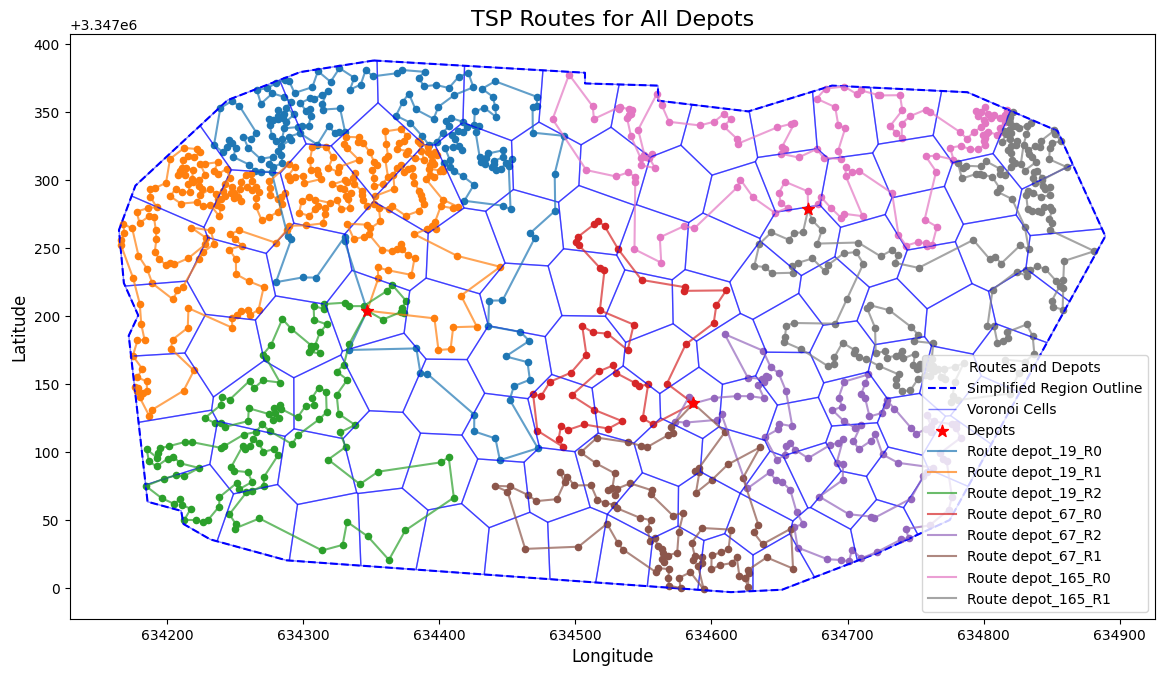

In [11]:
from macro_planning.visualize_micros import (
    plot_targets_by_route,
    plot_depot_micro_routes,
    plot_all_micro_routes
)

# plot_targets_by_route(region_outline_gdf, cells_gdf, targets_routes_gdf, depot_id=plot_depot_id)
# plot_depot_micro_routes(region_outline_gdf, cells_gdf, results, depot_point)
plot_all_micro_routes(region_outline_gdf, cells_gdf, micro_routes_gdf, depots_gdf)

## Write Data to Files

We store all of our calculated values in the GIS-standard GeoJSON format. 

This will allow us to easily display and transfer solution data in future applications, and port our results into common GIS tools.

In [12]:
# TODO: remove this function
# Only using this for the demo


def add_closest_depot_to_cells(cells_gdf, cells_depots_df):
    """
    Add a 'closest_depot' column to cells_gdf by looking up the value in cells_depots_df.

    Parameters:
    ----------
    cells_gdf : GeoDataFrame
        GeoDataFrame of cells, each identified by a unique cell_id.

    cells_depots_df : GeoDataFrame
        GeoDataFrame mapping cells to depots, with columns:
        - 'cell_id': Identifier for the cell.
        - 'closest_depot': Identifier of the closest depot.

    Returns:
    -------
    cells_gdf : GeoDataFrame
        Updated GeoDataFrame with a 'closest_depot' column added.
    """
    # Ensure the input GeoDataFrames have the necessary columns
    if 'cell_id' not in cells_gdf.columns or 'cell_id' not in cells_depots_df.columns:
        raise ValueError("Both cells_gdf and cells_depots_df must have a 'cell_id' column.")
    if 'closest_depot' not in cells_depots_df.columns:
        raise ValueError("cells_depots_df must have a 'closest_depot' column.")

    new_cells_gdf = cells_gdf.copy()

    # Merge the 'closest_depot' information into cells_gdf based on 'cell_id'
    new_cells_gdf = new_cells_gdf.merge(
        cells_depots_df[['cell_id', 'closest_depot']],
        on='cell_id',
        how='left'
    )

    return new_cells_gdf

cells_gdf = add_closest_depot_to_cells(cells_gdf, cells_depots_df)
# cells_gdf

In [13]:
cell_gdf_4326 = cells_gdf.copy().to_crs(visualization_crs)
# print(cell_gdf_4326.crs)

# Create a copy with only the 'geometry' column (Voronoi polygons)
voronoi_gdf = cell_gdf_4326.copy().drop(columns=["cell_centroid"])
voronoi_gdf.to_crs(visualization_crs, inplace=True)
voronoi_gdf.to_file(voronoi_partition_filename, driver="GeoJSON")

# Create a copy with only the 'cell_centroid' column and set it as the active geometry
centroid_gdf = cell_gdf_4326.copy().drop(columns=["geometry"])
centroid_gdf.set_geometry("cell_centroid", inplace=True)

centroid_gdf.set_crs(region_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_crs(visualization_crs, inplace=True)  # Reset the CRS explicitly
centroid_gdf.to_file(voronoi_centroids_filename, driver="GeoJSON")

# Write Depot locations to file
depots_gdf.to_crs(visualization_crs, inplace=True)
depots_gdf.to_file(depots_filename, driver="GeoJSON")

# Write Targets locations to file
targets_gdf.to_crs(visualization_crs, inplace=True)
targets_gdf.to_file(targets_plants_filename, driver="GeoJSON")

# Write Macro-routes to file
macro_routes_gdf.to_crs(visualization_crs, inplace=True)
macro_routes_gdf.to_file(macro_routes_filename, driver="GeoJSON")

# Write Micro-routes to file
micro_routes_gdf.to_crs(visualization_crs, inplace=True)
micro_routes_gdf.to_file(micro_routes_filename, driver="GeoJSON")

In [14]:
import os
import geopandas as gpd

def save_routes_as_waypoints(micro_routes_gdf, output_dir):
    """
    Save routes as .waypoints files for Mission Planner and QGroundControl.

    Parameters:
    - micro_routes_gdf (GeoDataFrame): GeoDataFrame containing routes.
        Must have columns: 'route_id' (unique identifier for each route) 
        and 'geometry' (LineString or MultiLineString of the route).
    - output_dir (str): Path to the directory where .waypoints files will be saved.
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for _, route in micro_routes_gdf.iterrows():
        route_id = route['route_id']
        geometry = route['geometry']

        # Ensure the geometry is a LineString or MultiLineString
        if geometry.is_empty or not geometry.is_valid:
            print(f"Skipping invalid or empty geometry for route {route_id}")
            continue
        
        # Extract waypoints from the route geometry
        waypoints = []
        if geometry.geom_type == 'LineString':
            waypoints = list(geometry.coords)
        elif geometry.geom_type == 'MultiLineString':
            for line in geometry:
                waypoints.extend(line.coords)

        # Format waypoints for .waypoints file
        waypoint_lines = ["QGC WPL 110"]  # File header
        for i, (lon, lat) in enumerate(waypoints, start=1):
            # Format: index, current, coord_frame, command, param1, param2, param3, param4, lat, lon, alt, autocontinue
            waypoint_line = f"{i}\t0\t3\t16\t0\t0\t0\t0\t{lat:.6f}\t{lon:.6f}\t10\t1"
            waypoint_lines.append(waypoint_line)

        # Write to file
        file_path = os.path.join(output_dir, f"{route_id}.waypoints")
        with open(file_path, 'w') as f:
            f.write('\n'.join(waypoint_lines))
        print(f"Saved route {route_id} as {file_path}")


In [15]:
save_routes_as_waypoints(micro_routes_gdf, waypoints_files_dir)

Saved route depot_19_R0 as ../outputs/interactive_proto\depot_19_R0.waypoints
Saved route depot_19_R1 as ../outputs/interactive_proto\depot_19_R1.waypoints
Saved route depot_19_R2 as ../outputs/interactive_proto\depot_19_R2.waypoints
Saved route depot_67_R0 as ../outputs/interactive_proto\depot_67_R0.waypoints
Saved route depot_67_R2 as ../outputs/interactive_proto\depot_67_R2.waypoints
Saved route depot_67_R1 as ../outputs/interactive_proto\depot_67_R1.waypoints
Saved route depot_165_R0 as ../outputs/interactive_proto\depot_165_R0.waypoints
Saved route depot_165_R1 as ../outputs/interactive_proto\depot_165_R1.waypoints


## Interactive Depot Map

Select a depot using ipywidgets dropdown to see information relevant to the given depot.

In [16]:
from macro_planning.interactive_map import display_interactive_map

interactive_map = display_interactive_map(
    region_contour_geojson,
    voronoi_partition_filename,
    depots_filename,
    # macro_routes=macro_routes_filename,
    micro_routes=micro_routes_filename
)
interactive_map

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [41]:
from plant_search.load_image import load_image
from rasterio.crs import CRS

image, transform, bounds, image_crs = load_image(region_image_path)

# Define your CRS
crs = CRS.from_wkt(image_crs.to_wkt())

# Convert to a dictionary
crs_dict = crs.to_dict()

# Print the dictionary
print(crs_dict)

Image CRS - EPSG:32613
{'proj': 'utm', 'zone': 13, 'datum': 'WGS84', 'units': 'm', 'no_defs': True}


In [50]:
from ipyleaflet import (
    Map, GeoJSON, LayersControl, ScaleControl, ImageOverlay
)
from plant_search.load_image import load_image
from shapely.geometry import shape
import json

from ipyleaflet.projections import projections

def plot_route_on_image(region_geojson, micro_routes_filename, orthophoto_path=None):

    # Get image data
    image, transform, bounds, image_crs = load_image(orthophoto_path)

    with open(region_geojson, "r") as f:
        region_contour_data = json.load(f)
    region_geometry = shape(region_contour_data['features'][0]['geometry'])
    region_center = region_geometry.centroid

    with open(micro_routes_filename, "r") as f:
        micro_routes_data = json.load(f)


    custom_crs = {
        'proj': 'utm',
        'zone': 13,
        'datum': 'WGS84',
        'units': 'm',
        'lat_0': 0,
        'lon_0': -105,
        'k': 0.9996,
        'x_0': 500000,
        'y_0': 0,
        'ellps': 'WGS84',
        'no_defs': True
    }
    

    m = Map(center=(region_center.y, region_center.x),
            zoom=16, scroll_wheel_zoom=True, crs=projections.EPSG4326)

    # Add orthophoto overlay
    overlay = ImageOverlay(url=orthophoto_path, bounds=bounds)
    m.add(overlay)

    # Add the region border to the map
    region_layer = GeoJSON(
        data=region_contour_data, 
        style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
        name=region_contour_data['name'])
    m.add(region_layer)

    routes_layer = GeoJSON(
        data=micro_routes_data, 
        style={'color': 'green', 'fillColor': 'green', 'opacity': 0.25, 'weight': 1},
        hover_style={'color': 'red' , 'opacity': 0.8, 'weight': 3},
        name=f'Micro Routes'
    )
    m.add(routes_layer)

    m.add(LayersControl(position='topright'))
    m.add(ScaleControl(position='bottomleft'))
    return m

m = plot_route_on_image(region_contour_geojson, micro_routes_filename, region_image_path)
m

Image CRS - EPSG:32613


AttributeError: ESRIImagery

Image CRS - EPSG:32613
EPSG:32613
EPSG:32613


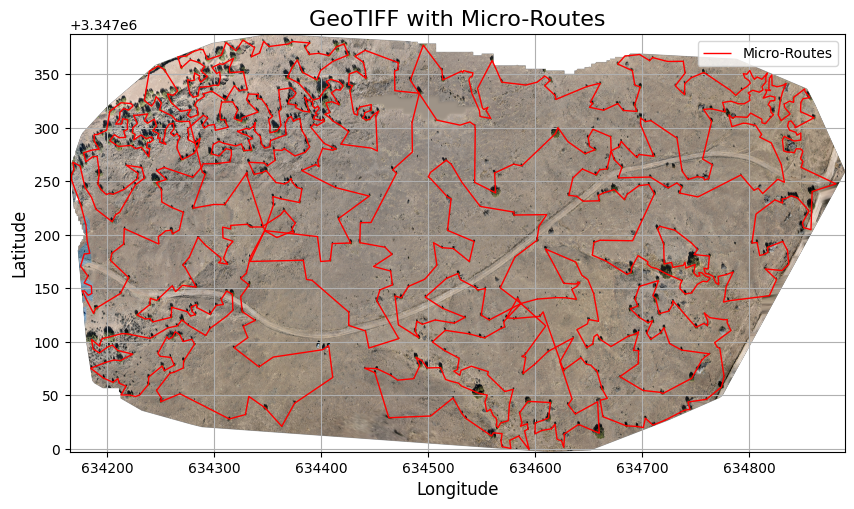

In [ ]:
from plant_search.load_image import load_image

import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_geotiff_with_routes(geotiff_path, micro_routes_gdf):
    """
    Plots a GeoTIFF image with routes from a GeoDataFrame on a matplotlib figure.

    Parameters:
    - geotiff_path (str): Path to the GeoTIFF file.
    - micro_routes_gdf (GeoDataFrame): GeoDataFrame containing route geometries.
        Must have a 'geometry' column with LineStrings or MultiLineStrings.
    """
    # Open the GeoTIFF file
    image, transform, bounds, image_crs = load_image(geotiff_path)
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    micro_routes_gdf = micro_routes_gdf.to_crs(region_crs)  # Match the GeoTIFF CRS

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the GeoTIFF image
    ax.imshow(image, cmap='gray', extent=extent, origin='upper')  # Adjust colormap as needed

    # Plot the routes from the GeoDataFrame
    micro_routes_gdf.plot(ax=ax, color='red', linewidth=1, label='Micro-Routes')

    # Add labels, legend, and grid
    ax.set_title("GeoTIFF with Micro-Routes", fontsize=16)
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.legend()
    ax.grid(True)

    # Show the plot
    plt.show()

plot_geotiff_with_routes(region_image_path, micro_routes_gdf)

## Display Targets w/ Cell Depot

- Each identified target is to be associated with a cell.
- Each cell is associated with a closest serving depot.

In [16]:
from ipyleaflet import GeoJSON, LayerGroup, CircleMarker, AntPath

def macro_route_display_layers(depot_data, macro_routes_data):
    macro_route_layers = {}
    for depot_feature in depot_data["features"]:
        properties = depot_feature["properties"]
        depot_id = properties.get("depot_id", "Unknown ID")
        coords = depot_feature["geometry"]["coordinates"]


        associated_routes = macro_routes_data.copy()
        associated_routes['features'] = [feature for feature in macro_routes_data['features']
                                        if feature['properties']['route_depot'] == depot_id]

        routes_layer = GeoJSON(
            data=associated_routes, 
            style={'color': 'green', 'fillColor': 'green', 'opacity': 0.25, 'weight': 1},
            hover_style={'color': 'red' , 'opacity': 0.8, 'weight': 3},
            name=f'Depot ID: {depot_id} macro routes'
        )

        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )

        routes_layergroup = LayerGroup(
            layers=(routes_layer, center_circle),
            name=f"{depot_id} Routes"
        )
        macro_route_layers[depot_id] = routes_layergroup

    return macro_route_layers


def target_display_layers(depot_data, cell_data, targets_data):
    targets_layers = {}

    # 1) Associate each target with parent cell
    cell_targets = {} # dict, where key is depot_id
    for cell_feature in cell_data['features']:
        cell_properties = cell_feature['properties']
        cell_id = cell_properties.get("cell_id", "Unknown ID")

        # associated_targets = targets_data.copy()
        associated_targets = [feature for feature in targets_data['features']
                                        if feature['properties']['parent_cell_id'] == cell_id]
        cell_targets[cell_id] = associated_targets


    # 2) Associate each cell with depot
    depot_to_targets = {}
    for depot_feature in depot_data["features"]:
        properties = depot_feature["properties"]
        depot_id = properties.get("depot_id", "Unknown ID")
        coords = depot_feature["geometry"]["coordinates"]

        # Find cells associated with each depot for coloration
        associated_targets = targets_data.copy()
        associated_cell_ids = [feature['properties']['cell_id'] for feature in cell_data['features']
                                        if feature['properties']['closest_depot'] == depot_id]
        depot_targets = []
        for cell_id in associated_cell_ids:
            depot_targets += cell_targets[cell_id]
        associated_targets['features'] = depot_targets

        depot_to_targets[depot_id] = associated_targets

        # 3) Create targets layers

        # Display as Markers
        targets_layer = GeoJSON(
            data=associated_targets, 
            style={'color': 'red', 'fillColor': 'lightblue', 'opacity': 0.5, 'weight': 2},
            name=associated_targets['name'])
        
        # Display as Circle Marker points
        # targets_layer = GeoJSON(
        #     data=associated_targets,
        #     style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'fillOpacity':0.6},
        #     hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
        #     point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
        #     name=associated_targets['name']
        # )
        
        center_circle = CircleMarker(
            location=[coords[1], coords[0]],  # GeoJSON uses (lon, lat), Folium expects (lat, lon)
            radius=5,  # Circle radius in meters
            color='black', fill=True, fill_color='red',
            fill_opacity=0.9, weight=1,
            tooltip=f"Depot ID: {depot_id}\nRadius: {depot_radius}m"
        )
        
        targets_layergroup = LayerGroup(
            layers=(targets_layer, center_circle),
            name=f"{depot_id} Targets"
        )
        targets_layers[depot_id] = targets_layergroup

    return targets_layers

In [17]:
from ipyleaflet import Map, Choropleth, GeoJSON, WidgetControl, FullScreenControl, GeomanDrawControl
from ipywidgets import Select, Dropdown
import matplotlib as plt
from shapely.geometry import mapping, shape
import json
import time

# Load Data for mapping
# =====================

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi cells
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)

with open(targets_plants_filename, "r") as f:
    targets_data = json.load(f)

with open(macro_routes_filename, "r") as f:
    macro_routes_data = json.load(f)

# Set up interactive layer selections
# ===================================
all_depot_layers = depot_selection_layers(depot_data, voronoi_data) # Dict of layer instances
list_depots = list(all_depot_layers.keys())

# Targets associated with each depot
all_targets_layers = target_display_layers(depot_data, voronoi_data, targets_data)

# Routes associated with each depot
all_routes_layers = macro_route_display_layers(depot_data, macro_routes_data)

# Depot select widget
depot_select = Dropdown(
    options=list_depots,
    value=list_depots[0],
    description='Depot:',
    disabled=False
)


def focus_depot_on_select(selected_depot_id):
    
    # Extract the selected depot's feature from depot_data
    selected_depot = next(
        feature for feature in depot_data['features'] if feature['properties']['depot_id'] == selected_depot_id
    )
    
    # Get the depot's center coordinates (assuming Point geometry)
    depot_lon, depot_lat = selected_depot['geometry']['coordinates']
    
    # Get depot range (example property, replace with actual if different)
    depot_range = selected_depot['properties'].get('min_enclosing_rad', 400)  # Default to 500m if not provided
    buffer = -3  # Add an extra buffer
    
    # Convert range + buffer to approximate degree offsets
    lat_offset = (depot_range + buffer) / 111000 # 111,000 meters per degree of latitude
    # lon_offset = lat_offset / abs(depot_lat / 360) # Adjust for longitude scaling at latitude
    lon_offset = lat_offset / math.cos(math.radians(depot_lat))

    # Calculate bounding box
    min_lat = depot_lat - lat_offset
    max_lat = depot_lat + lat_offset
    min_lon = depot_lon - lon_offset
    max_lon = depot_lon + lon_offset
    
    # Fit the map to the bounding box
    m3.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])


def on_depot_select(change):
    # Change depot display layers
    old_layer = all_depot_layers[change['old']]
    new_layer = all_depot_layers[change['new']]
    m3.substitute(old_layer, new_layer)
    time.sleep(0.1) # Race condition in layer replacement

    # Swap out our displayed targets
    old_targets = all_targets_layers[change['old']]
    new_targets = all_targets_layers[change['new']]
    m3.substitute(old_targets, new_targets)
    time.sleep(0.1) # Race condition in layer replacement

    # Swap out our displayed routes
    old_routes = all_routes_layers[change['old']]
    new_routes = all_routes_layers[change['new']]
    m3.substitute(old_routes, new_routes)
    time.sleep(0.1) # Race condition in layer replacement

    selected_depot_id = change['new']
    # focus_depot_on_select(selected_depot_id)


depot_select.observe(on_depot_select, names='value')




# Set up interactive map
# ======================
m3 = Map(center=(region_center.y, region_center.x), 
         zoom=16, zoom_snap=0.25, zoom_delta=0.25, scroll_wheel_zoom=True
)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
    name=region_contour_data['name'])
# region_layer.pmIgnore = True  # Lock this layer
m3.add(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.25, 'weight': 1},
    name=voronoi_data['name'])
voronoi_layer.pmIgnore = True  # Lock this layer
m3.add(voronoi_layer)

# Always keep depot points visible
depot_points = GeoJSON(
    data=depot_data,
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=depot_data['name']
)
m3.add(depot_points)

# Add depot selection dropdown widget
depot_select_control = WidgetControl(widget=depot_select, position='bottomright')
m3.add(depot_select_control)

# Add (interactive + dynamic) depot layer
depot_layer = all_depot_layers[depot_select.value] # Whichever is initially set
m3.add(depot_layer)

# Add interactive targeting layer
targets_layer = all_targets_layers[depot_select.value]
m3.add(targets_layer)

# Add interactive routes layer
routes_layer = all_routes_layers[depot_select.value]
m3.add(routes_layer)

draw_control = GeomanDrawControl()
draw_control.circlemarker = {}
draw_control.rotate = False
draw_control.cut = False
draw_control.drag = False
m3.add(draw_control)

# m3.add(FullScreenControl(position='topleft'))
m3.add(LayersControl(position='topright', collapsed=False))
m3.add(ScaleControl(position='bottomleft'))
m3

NameError: name 'depot_selection_layers' is not defined

In [ ]:
# print(all_routes_layers.keys())
# print(all_routes_layers)
# print(depot_data)
print(m3.bounds)
print(m3.zoom)

## Show Routes from each Depot

- Show cells associated with each depot
- Show routes to cover all cells from each depot

In [48]:
# micro_routes_gdf

In [49]:
from ipyleaflet import Map, Polyline, LayerGroup, basemaps
from ipywidgets import HTML
import geopandas as gpd

def plot_routes_on_map(micro_routes_gdf):
    """
    Plot a GeoDataFrame of polylines on an ipyleaflet map.

    Parameters:
    - micro_routes_gdf: GeoDataFrame
        GeoDataFrame containing route polylines with columns for 'route_id' and 'geometry'.

    
    Returns:
    - m: ipyleaflet.Map
        Interactive ipyleaflet map with plotted routes.
    """
    
    # Create a layer group to hold all the route polylines
    route_layer_group = LayerGroup(name="Micro routes")
    
    for _, row in micro_routes_gdf.iterrows():
        route_id = row['route_id']
        # coords = [(point.y, point.x) for point in row['geometry'].coords]
        coords = [(lat, lon) for lon, lat in row['geometry'].coords]
        
        # Create a Polyline for the route
        polyline = Polyline(
            locations=coords,
            color="blue",
            fill=True,
            weight=4,
            opacity=0.7,
            name=route_id
        )
        
        # Add a tooltip with the route_id
        # polyline.popup = HTML(f"<b>Route ID:</b> {route_id}")
        route_layer_group.add(polyline)
    
    return route_layer_group


In [ ]:
from ipyleaflet import Choropleth, GeoJSON, WidgetControl, FullScreenControl, GeomanDrawControl
from ipywidgets import Select, Dropdown
import matplotlib as plt
from shapely.geometry import mapping, shape
import json
import time

# Load Data for mapping
# =====================

# Load the GeoJSON region outline
with open(region_contour_geojson, "r") as f:
    region_contour_data = json.load(f)
region_geometry = shape(region_contour_data['features'][0]['geometry'])
region_center = region_geometry.centroid

# Load Voronoi cells
with open(voronoi_partition_filename, "r") as f:
    voronoi_data = json.load(f)

# Load depot locations
with open(depots_filename, "r") as f:
    depot_data = json.load(f)


all_depot_layers = depot_selection_layers(depot_data, voronoi_data) # Dict of layer instances
list_depots = list(all_depot_layers.keys())

# Depot select widget
depot_select = Dropdown(
    options=list_depots,
    value=list_depots[0],
    description='Depot:',
    disabled=False
)

def on_depot_select(change):
    # Change depot display layers
    old_layer = all_depot_layers[change['old']]
    new_layer = all_depot_layers[change['new']]
    m4.substitute(old_layer, new_layer)

depot_select.observe(on_depot_select, names='value')



# Set up interactive map
# ======================
m4 = Map(center=(region_center.y, region_center.x), 
         zoom=16, zoom_snap=0.25, zoom_delta=0.25, scroll_wheel_zoom=True
)

# Add the region border to the map
region_layer = GeoJSON(
    data=region_contour_data, 
    style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
    name=region_contour_data['name'])
# region_layer.pmIgnore = True  # Lock this layer
m4.add(region_layer)

# Add Voronoi polygons
voronoi_layer = GeoJSON(
    data=voronoi_data, 
    style={'color': 'blue', 'fillColor': 'lightblue', 'opacity': 0.25, 'weight': 1},
    name=voronoi_data['name'])
voronoi_layer.pmIgnore = True  # Lock this layer
m4.add(voronoi_layer)

# Always keep depot points visible
depot_points = GeoJSON(
    data=depot_data,
    style={'color': 'black', 'radius':3, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
    hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
    point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
    name=depot_data['name']
)
m4.add(depot_points)

# Add depot selection dropdown widget
depot_select_control = WidgetControl(widget=depot_select, position='bottomright')
m4.add(depot_select_control)

# Add (interactive + dynamic) depot layer
depot_layer = all_depot_layers[depot_select.value] # Whichever is initially set
m4.add(depot_layer)


reprojected_route = micro_routes_gdf.to_crs(visualization_crs)
row = reprojected_route.loc[0]
route_id = row['route_id']
coords = [(lat, lon) for lon, lat in row['geometry'].coords]

# Create a Polyline for the route
polyline = Polyline(
    locations=coords,
    color="blue",
    fill=False,
    weight=4,
    opacity=0.7,
    name=route_id
)
m4.add(polyline)

# routes_layer = plot_routes_on_map(micro_routes_gdf)
# m4.add(routes_layer)   

draw_control = GeomanDrawControl()
draw_control.circlemarker = {}
draw_control.rotate = False
draw_control.cut = False
draw_control.drag = False
m4.add(draw_control)

m4.add(FullScreenControl(position='topleft'))
m4.add(LayersControl(position='topright', collapsed=False))
m4.add(ScaleControl(position='bottomleft'))
m4

In [ ]:
row = micro_routes_gdf.loc[0]
route_id = row['route_id']
# coords = [(point.y, point.x) for point in row['geometry'].coords]
coords = [(lat, lon) for lon, lat in row['geometry'].coords]
print(coords)

